In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from metrics import treatment_effect

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
# Load dataset
from datasets_retrospective import load_sprint_dataset
outcomes, features, intervention, cat_feats, num_feats = load_sprint_dataset(location='datasets/SPRINT_POP/Datasets/', outcome='PRIMARY')

(9361, 27)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:117: SettingWithCopyWar

In [3]:
# intervention = intervention.dropna()
# features = features.loc[intervention.dropna().index]
# outcomes = outcomes.loc[intervention.dropna().index]

In [4]:
# best sprint
# # Specify categorical and numeric features used for training the model
# cat_feats=['Baseline_Smoke_status', 'Baseline_History_Cardiovascular_Disease']
# num_feats=['Baseline_Glucose']
# Oat 
# # Specify categorical and numeric features used for training the model
# cat_feats=['Sex', 'Race', 'Baseline_New_York_Heart_Association_Highest_Class']
# num_feats=['Baseline_Age']

# # Specify categorical and numeric features used for training the model
# cat_feats=['Sex', 'Race', 'Baseline_History_Diabetes']
# num_feats=['Baseline_Age']

# # Specify categorical and numeric features used for training the model
# cat_feats=['Sex', 'Race', 'Baseline_Ejection_Fraction_50']
# num_feats=['Baseline_Age']

# # Specify categorical and numeric features used for training the model
# cat_feats=['Sex', 'Race', 'Baseline_Two_or_more_Aspirin_Warfarin_Thienopyridine']
# num_feats=['Baseline_Age']

# best
# Specify categorical and numeric features used for training the model
# cat_feats=['Sex', 'Race', 'Baseline_One_or_more_Aspirin_Warfarin_Thienopyridine']
# num_feats=['Baseline_Age']

# best division
# Specify categorical and numeric features used for training the model
# cat_feats=['Sex', 'Race', 'Baseline_One_or_more_Aspirin_Warfarin_Thienopyridine', 'Baseline_History_Diabetes']
# num_feats=['Baseline_Age']

# best bari 2d
# Specify categorical and numeric features used for training the model
# cat_feats=['Sex', 'Race', 'Baseline_Beta_Blocker', 
#           'Baseline_Calcium_Blocker']
# num_feats=['Baseline_Age', 'Baseline_Standing_Diastolic_Blood_Pressure', 'Baseline_Standing_Systolic_Blood_Pressure']

In [127]:
# # Specify categorical and numeric features used for training the model
# cat_feats=['Race', 'Baseline_Smoke_status']
# num_feats=['Baseline_Triglycerides']

In [33]:
# Preprocess feature data
from preprocessing import Preprocessor
features_prep = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [58]:
# # Hyper-parameters to train CMHE model
# k = 1 # number of underlying base survival phenotypes
# g = 2 # number of underlying treatment effect phenotypes.
# layers = [] # number of neurons in each hidden layer.
# random_seed = 3
# iters = 100 # number of training epochs
# learning_rate = 0.001
# batch_size = 256 
# patience = 5
# optimizer = "Adam"
# gate_l2_penalty = 1e-3

In [5]:
# Hyper-parameters to train SPARSE model
k = 2 # number of underlying base survival phenotypes
random_seed = 105
n_epochs = 100 # number of training epochs
step_size = 1e-5

In [34]:
from models.scs.model import SparseCoxSubgroup

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = SparseCoxSubgroup(k=k, random_seed=random_seed, n_epochs=n_epochs, n_restarts=1, step_size=step_size, alpha=0.)

model.fit(features_prep.values, outcomes.time.values, outcomes.event.values, (intervention=='SBP target <120mm Hg').values)

Restarts:   0%|          | 0/1 [00:00<?, ?it/s]


 6508.711344934423 6925.493312645704 13434.204657580127
268725.25117528246 4.218991794141097e-12

 6002.584590188411 6606.164720713565 12608.749310901976


190953.23785403362 4.061365097787432e-22

 5851.966995702225 6600.014751911833 12451.981747614058
146594.09291958396 5.965299180732514e-25

 5773.588155987114 6594.002097248267 12367.590253235381


113112.4126132048 5.143563501579123e-24

 5717.9589071798155 6588.216549207175 12306.17545638699
86485.80640862497 2.356542512142384e-22

 5671.90267521349 6582.760149120031 12254.662824333522


69449.64860193766 9.20841400148631e-21

 5632.128606793431 6577.603013740869 12209.7316205343
59660.40319668294 2.6588845658803023e-19


...

2570.4973181997543 0.013715652940875601

 4940.68797686534 6493.836165472598 11434.524142337938
2529.7570684908023 0.014147970169747026

 4938.361133671378 6493.756062160844 11432.117195832223


2489.9161735598923 0.01459098555595356

 4936.056681906592 6493.67818625174 11429.734868158332
2450.9462359042654 0.015044578073969151

 4933.764692589297 6493.602462819812 11427.367155409109


2412.8207401521304 0.015508807504622172

 4931.533640502366 6493.528813682264 11425.06245418463


Restarts: 100%|██████████| 1/1 [00:16<00:00, 16.12s/it]

2375.5184580658897 0.015983906278393564

 4929.333352113388 6493.457157780264 11422.790509893654
2339.010937037581 0.0164699709462225

 4927.186446326536 6493.387412706562 11420.573859033098


In [141]:
# from models.cmhe import DeepCoxMixturesHeterogenousEffects

# torch.manual_seed(random_seed)
# np.random.seed(random_seed)

# # Instantiate the CMHE model on all data
# model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

# model = model.fit(features_prep, outcomes.time, outcomes.event, intervention=='Niacin', val_data=None, iters=iters, 
#                   learning_rate=learning_rate, batch_size=batch_size, 
#                   optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:15<00:00,  6.58it/s]


In [142]:
# zeta_probs = model.predict_latent_phi(features_prep)
# zeta = np.argmax(zeta_probs, axis=1)

In [35]:
zeta = model.predict_proba(features_prep.values).argmax(axis=1)

In [13]:
print((zeta == 0).sum())
print((zeta == 1).sum())

5022
4800


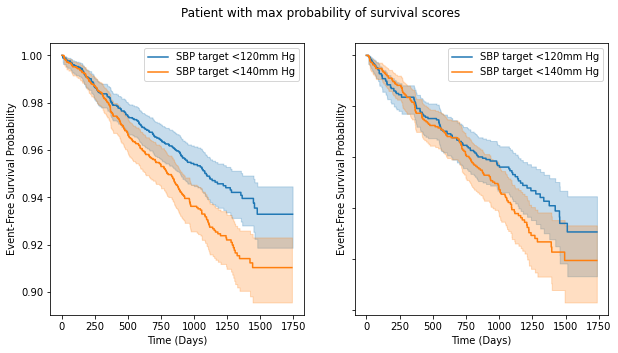

In [36]:
from auton_survival import reporting
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['SBP target <120mm Hg', 'SBP target <140mm Hg'], loc="upper right")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# Split the PEACE data into training and test data
x_train, x_test, y_train, y_test = train_test_split(features_prep, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Lipid Fibrate'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 3694
Number of test data points: 1584


In [16]:
x_tr = x_train
t_tr = y_train['time']
e_tr = y_train['event']
a_tr = intervention[y_train.index]=='Lipid Fibrate'

x_te = x_test
t_te = y_test['time']
e_te = y_test['event']
a_te = intervention[y_test.index]=='Lipid Fibrate'

In [17]:
from models.scs.model import SparseCoxSubgroup

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = SparseCoxSubgroup(k=k, random_seed=random_seed, n_epochs=n_epochs, n_restarts=1, step_size=step_size, alpha=0.)

model.fit(x_tr.values, t_tr.values, e_tr.values, a_tr.values)

Restarts:   0%|          | 0/1 [00:00<?, ?it/s]


 6766.56256514811 2645.770743080898 9412.333308229008
293961126.0192749 1.0590847313572378e-158

 6679.28317479637 2584.037954131119 9263.32112892749
176638729.71025002 3.13755411157731e-71

 6512.998159111286 2583.713157106172 9096.711316217457
116140278.63893168 2.1786978046342056e-70

 6343.814025748962 2583.303449422854 8927.117475171817


76089478.37289758 1.9864218219873842e-69

 6199.532814165825 2582.904550000942 8782.437364166766
49648853.514992565 2.099964524606141e-68

 6043.989943957702 2582.5169478514176 8626.50689180912
32289496.016926922 2.3674873293366508e-67

 5903.978061174568 2582.1412016106106 8486.119262785178
20924511.243392527 4.885707887639669e-66



 5756.3190975264615 2581.7777419489107 8338.096839475373
13511169.484512204 1.1054033932014936e-64

 5604.89692623701 2581.4279143537933 8186.324840590803
8711041.977223223 2.9434468983917206e-63

 5464.77307880882 2581.092792584035 8045.865871392855
5618593.1462175045 1.0665541202777072e-61



 5317.190591304094 2580.7734336323692 7897.964024936463
3633402.897011301 4.439488986715005e-60

 5179.669763435003 2580.4710176153512 7760.140781050354
2364287.3971564025 2.9149457698056005e-58

 5054.254124740593 2580.185397625365 7634.4395223659585
1552012.6769745555 3.0154729381789535e-56

 4924.118832630205 2579.9156855872398 7504.034518217445


...

1407.4737582044763 5.824587410556298e-10

 3052.0303824456228 2566.982791539119 5619.013173984742
1379.5303710347491 7.570824123425861e-10

 3049.796813542373 2566.899099354055 5616.695912896428
1352.4722629392395 9.812261991318075e-10

 3037.288170788217 2566.8167999536045 5604.1049707418215
1326.1647847036065 1.2647352216132186e-09



 3033.1882341849587 2566.7358774429 5599.924111627859
1300.5362978367145 1.6318505591326285e-09

 3020.8969784224237 2566.656253556947 5587.553231979371
1275.713708340708 2.090120874172116e-09

 3019.484905054727 2566.5780595542997 5586.0629646090265
1251.5545161505459 2.6795448114805513e-09



 3010.91102707344 2566.5011065539366 5577.4121336273765
1228.1150038793276 3.413356552545915e-09

 3005.2901354947358 2566.425490421963 5571.715625916699
1205.3570296444884 4.3632509598192515e-09

 2997.120614197931 2566.351060404224 5563.471674602155
1183.1925893120524 5.527877546020783e-09


Restarts: 100%|██████████| 1/1 [00:07<00:00,  7.03s/it]


 2995.905070830392 2566.2779647344555 5562.183035564847


In [135]:
# from models.cmhe import DeepCoxMixturesHeterogenousEffects

# torch.manual_seed(random_seed)
# np.random.seed(random_seed)

# # Instantiate the CMHE model
# model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

# model = model.fit(x_tr, t_tr, e_tr, a_tr, iters=iters, 
#                   learning_rate=learning_rate, batch_size=batch_size, 
#                   optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:08<00:00, 11.17it/s]


In [18]:
zeta_probs_train = model.predict_proba(x_tr.values)
zeta_train =  np.argmax(zeta_probs_train, axis=1)

zeta_probs_test = model.predict_proba(x_te.values)
zeta_test =  np.argmax(zeta_probs_test, axis=1)

In [136]:
# zeta_probs_train = model.predict_latent_phi(x_tr)
# zeta_train =  np.argmax(zeta_probs_train, axis=1)

# zeta_probs_test = model.predict_latent_phi(x_te)
# zeta_test =  np.argmax(zeta_probs_test, axis=1)

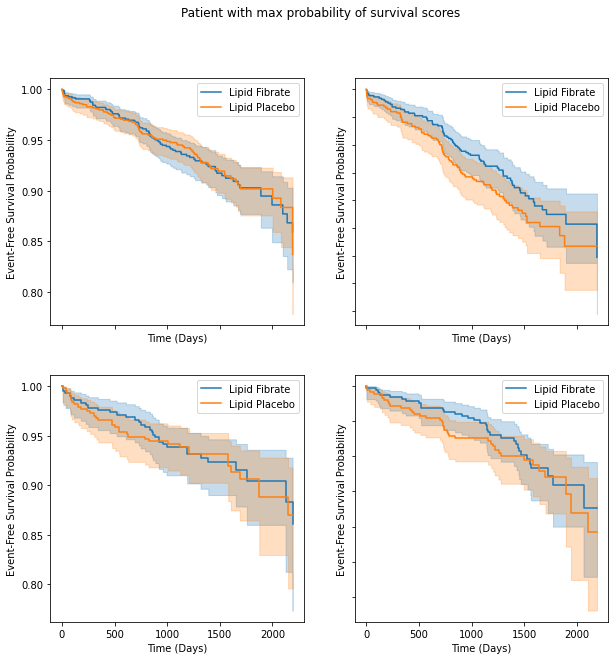

In [19]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (10, 10))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(y_train[zeta_train == 0], a_tr[zeta_train == 0], ax=ax1)
reporting.plot_kaplanmeier(y_train[zeta_train == 1], a_tr[zeta_train == 1], ax=ax2)
reporting.plot_kaplanmeier(y_test[zeta_test == 0], a_te[zeta_test == 0], ax=ax3) 
reporting.plot_kaplanmeier(y_test[zeta_test == 1], a_te[zeta_test == 1], ax=ax4)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Lipid Fibrate', 'Lipid Placebo'], loc="upper right")
plt.show()
# First row is training data
# Second row is test data
# First column is zeta 0
# Second column is zeta 1